In [7]:
import numpy as np
import pandas as pd

from scipy.optimize import curve_fit
from scipy.optimize import minimize

import matplotlib.pyplot as plt

import time

In [2]:
df_k = pd.read_csv('N2.csv')

In [3]:
df_k = pd.read_csv('O2_v1.csv')

In [3]:
df_test = pd.read_csv('N2_test.csv')

In [8]:
def mape_loss(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    # print(y_true, y_pred)

    errors = np.abs((y_true - y_pred) / y_true)

    mape = np.mean(errors) * 100
    
    return mape

In [9]:
def k_model_poly(T, *coeffs):
    x = T**(-1/3)

    result = 0.0
    for k, coeff in enumerate(coeffs[:]):
        result += coeff * (x ** k)

    return result 
    # return result + coeffs[-1]*(x + 1/x)

# def k_model_poly(T, *coeffs):
#     x = T**(-1/3)
# 
#     n_total = len(coeffs) 
#     
#     n_poly = n_total // 2
#     n_poly2 = n_total - n_poly
#     
#     # n_poly = n_total - 2
# 
#     result = 0.0
# 
#     for k in range(n_poly):
#         result += coeffs[k] * x**k
#     # result = np.exp(result)
#     
#     temp = 0.0
#     for j in range(n_poly2):        
#         temp += coeffs[n_poly + j] * x**j
#     
#     result = result + np.log(temp)
#     # result += coeffs[-1] * np.log(x)
#     return result


# def fit_poly(df):
#     params_arr = []
#     pred_df = pd.DataFrame(index=df.index)
#     for i in range(1, df.shape[1]):
#         coeffs = []
#         pred = []
#         best_mape = np.inf
#         print(i)
#         
#         for coeff_num in range(4, 8): 
#             params, _ = curve_fit(k_model_poly, df.iloc[:, 0], np.log(df.iloc[:, i]), p0=np.ones(coeff_num), method='lm')
#             
#             k_pred = np.exp(k_model_poly(df_k.iloc[:, 0], *params))
#             mape_poly = mape_loss(df.iloc[:, i], k_pred)
#             print(mape_poly)
#             if mape_poly < best_mape:
#                 coeffs = params
#                 pred = k_pred
#                 print(coeff_num)
#         print(coeffs)
#         params_arr.append(coeffs)
#         pred_df[i-1] = pred
#     
#     return params_arr, pred_df

def fit_poly(df):
    params_arr = []
    pred_df = pd.DataFrame(index=df.index)
    
    for i in range(1, df.shape[1]):
        coeffs = []
        pred = []
        best_mape = np.inf
        
        # Логарифмы и нормировка
        y_log = np.log(df.iloc[:, i])
        norm_factor = np.abs(y_log).max()


        y_norm = y_log / norm_factor
        
        for coeff_num in range(4, 8): 
            params, _ = curve_fit(
                k_model_poly,
                df.iloc[:, 0], 
                y_norm,  
                p0=np.ones(coeff_num), 
                method='lm'
            )
            
            params1 = params * norm_factor
            y_pred = k_model_poly(df.iloc[:, 0], *params1)
            
            # y_pred_log = y_pred_norm * norm_factor
            
            k_pred = np.exp(y_pred)
            
            mape_poly = mape_loss(df.iloc[:, i], k_pred)
            # print(mape_poly)
            
            if mape_poly < best_mape:
                best_mape = mape_poly
                coeffs = params1  # параметры остаются как есть
                pred = k_pred
        
        params_arr.append(coeffs)
        pred_df[i-1] = pred
    
    return params_arr, pred_df

In [9]:
import json

start_time = time.time()

coeffs, pred_values = fit_poly(df_k)

end_time = time.time()
execution_time = end_time - start_time
print(f"Время выполнения: {execution_time:.4f} секунд")

print(coeffs)
params_list = [p.tolist() for p in coeffs]
print(params_list)
json.dump(params_list, open('coeffs.json', 'w'))


0.10061170028081384
0.0051799035878534825
0.0013993131476966658
0.0006055158238961011
Время выполнения: 0.2726 секунд
[array([-1.99061375e+01, -2.28196623e+02,  2.06244361e+03, -5.15359015e+03,
       -1.09669160e+05,  1.14433871e+06, -3.48051539e+06])]
[[-19.90613753160833, -228.19662342533732, 2062.4436065512446, -5153.5901495082135, -109669.15976981116, 1144338.713019953, -3480515.392648889]]


In [46]:
from FHO_FR_VV.k_vv_mm import k_vv_mm
from FHO_FR_VV.particles_data import *
import json

all_coeffs = []
v_max = 7

n_points = 20
T_min, T_max = 1000, 15000  # Диапазон
T_data = np.linspace(T_min, T_max, n_points)
T_data = np.sort(T_data)  # если нужно отсортировать

for v1 in range(v_max):
    layer_v2 = []
    
    for v2 in range(v_max):
        layer_v1p = []
        
        for v1p in range(v_max):
            layer_v2p = []
            
            for v2p in range(v_max):

                # --- формируем df_k ---
                df_k = pd.DataFrame()
                df_k['T'] = T_data
                
                column_values = []
                for T in T_data:
                    k = k_vv_mm(O2, O2, v1, v2, v1p, v2p, T)
                    column_values.append(k)
                    print(k)
                
                df_k['k'] = column_values
                
                column_values = np.array(column_values)

                if np.any(column_values <= 0):
                    layer_v2p.append(None)
                    continue

                # --- обучаем (НЕ МЕНЯЕМ) ---
                coeffs, _ = fit_poly(df_k)

                # coeffs — список, берем первый элемент
                layer_v2p.append(coeffs[0].tolist())
            
            layer_v1p.append(layer_v2p)
        
        layer_v2.append(layer_v1p)
    
    all_coeffs.append(layer_v2)
    
with open('coeffs_4d.json', 'w') as f:
    json.dump(all_coeffs, f)

0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0


KeyboardInterrupt: 

In [5]:
from FHO_FR_VV.k_vv_mm import k_vv_mm
from FHO_FR_VV.particles_data import *
import json

v_max = 6
all_coeffs = {}

n_points = 30
T_min, T_max = 300, 10000  
T_data = np.linspace(T_min, T_max, n_points)
T_data = np.sort(T_data)

for v in range(v_max + 1):
    for vp in range(v_max + 1):

        transitions = []

        # только нужные 4 перехода
        if v + 1 <= v_max and vp + 1 <= v_max:
            transitions.append((v+1, v, vp, vp+1))

        if v - 1 >= 0 and vp - 1 >= 0:
            transitions.append((v-1, v, vp, vp-1))

        if v - 1 >= 0 and vp + 1 <= v_max:
            transitions.append((v, v-1, vp, vp+1))

        if v + 1 <= v_max and vp - 1 >= 0:
            transitions.append((v, v+1, vp, vp-1))

        for (v1, v2, v1p, v2p) in transitions:

            df_k = pd.DataFrame()
            df_k['T'] = T_data

            column_values = []

            for T in T_data:
                # print((v1, v2, v1p, v2p))
                # k = k_vv_mm(O2, O2, v1, v1p, v2, v2p, T)
                # print(k)
                k = k_vv_mm(O2, O2, v1, v2, v1p, v2p, T)
                # print(k)
                column_values.append(k)

            column_values = np.array(column_values)

            # if np.any(column_values <= 0):
            #     all_coeffs[(v1, v2, v1p, v2p)] = None
            #     continue
            if np.any(column_values <= 0):
                key = f"{v1}_{v2}_{v1p}_{v2p}"  # делаем строковый ключ
                all_coeffs[key] = None
                continue

            df_k['k'] = column_values

            coeffs, _ = fit_poly(df_k)
            # print(coeffs)
            # all_coeffs[(v1, v2, v1p, v2p)] = coeffs[0].tolist()
            key = f"{v1}_{v2}_{v1p}_{v2p}"
            all_coeffs[key] = coeffs[0].tolist()

with open('coeffs_sparse2.json', 'w') as f:
    json.dump(all_coeffs, f)

In [10]:
from FHO_FR_VV.k_vv_mm import k_vv_mm
from FHO_FR_VV.particles_data import *
import json

v_max = 6
all_coeffs = {}

n_points = 30
T_min, T_max = 300, 10000  
T_data = np.linspace(T_min, T_max, n_points)
T_data = np.sort(T_data)

for v in range(v_max + 1):
    for vp in range(v_max + 1):

        transitions = []

        # только нужные 4 перехода
        if v + 1 <= v_max and vp + 1 <= v_max:
            transitions.append((v+1, v, vp, vp+1))

        if v - 1 >= 0 and vp - 1 >= 0:
            transitions.append((v-1, v, vp, vp-1))

        if v - 1 >= 0 and vp + 1 <= v_max:
            transitions.append((v, v-1, vp, vp+1))

        if v + 1 <= v_max and vp - 1 >= 0:
            transitions.append((v, v+1, vp, vp-1))

        for (v1, v2, v1p, v2p) in transitions:

            df_k = pd.DataFrame()
            df_k['T'] = T_data

            column_values = []

            for T in T_data:
                # print((v1, v2, v1p, v2p))
                # k = k_vv_mm(O2, O2, v1, v1p, v2, v2p, T)
                # print(k)
                k = k_vv_mm(N2, N2, v1, v2, v1p, v2p, T)
                # print(k)
                column_values.append(k)

            column_values = np.array(column_values)

            # if np.any(column_values <= 0):
            #     all_coeffs[(v1, v2, v1p, v2p)] = None
            #     continue
            if np.any(column_values <= 0):
                key = f"{v1}_{v2}_{v1p}_{v2p}"  # делаем строковый ключ
                all_coeffs[key] = None
                continue

            df_k['k'] = column_values

            coeffs, _ = fit_poly(df_k)
            # print(coeffs)
            # all_coeffs[(v1, v2, v1p, v2p)] = coeffs[0].tolist()
            key = f"{v1}_{v2}_{v1p}_{v2p}"
            all_coeffs[key] = coeffs[0].tolist()

with open('coeffs_sparse_N2.json', 'w') as f:
    json.dump(all_coeffs, f)

In [36]:
# Возьмите один переход и проверьте оба порядка
T_test = 300

# Вариант A: (v+1, v, vp, vp+1) → i1=v+1, f1=v, i2=vp, f2=vp+1
k1 = k_vv_mm(O2, O2, 1, 0, 0, 1, T_test)  # v=0, vp=0? Уточните

# Вариант B: переставили молекулы местами
k2 = k_vv_mm(O2, O2, 0, 1, 1, 0, T_test)  # i1=0, f1=1, i2=1, f2=0

print(f"k1 = {k1:.2e}")
print(f"k2 = {k2:.2e}")
print(f"Отношение k1/k2 = {k1/k2:.2f}")

k1 = 8.03e-15
k2 = 8.03e-15
Отношение k1/k2 = 1.00


In [28]:
def k_lookup(coeffs_dict, v1, v2, v1p, v2p, T):

    key = f"{v1}_{v2}_{v1p}_{v2p}"
    coeffs = coeffs_dict.get(key)

    if coeffs is None:
        return 0.0

    x = T**(-1/3)
    return np.exp(sum(c * x**i for i, c in enumerate(coeffs)))

k_lookup(all_coeffs, 1, 2, 2, 1, 300)

3.3021523371502417e-14

In [31]:
import json

for k in all_coeffs.keys():
    if not isinstance(k, (str, int, float, bool, type(None))):
        print("BAD KEY:", k, type(k))
        
with open('coeffs_sparse.json', 'w') as f:
    json.dump(all_coeffs, f)

BAD KEY: (1, 0, 1, 2) <class 'tuple'>
BAD KEY: (0, 1, 2, 1) <class 'tuple'>
BAD KEY: (2, 1, 0, 1) <class 'tuple'>
BAD KEY: (1, 2, 1, 0) <class 'tuple'>


TypeError: keys must be str, int, float, bool or None, not tuple

In [7]:
# coeffs

In [8]:
# pred_values

In [9]:
for i in range(1, df_test.shape[1]):
    k_pred = np.exp(k_model_poly(df_test.iloc[:, 0], *coeffs[i-1]))
    # print(k_pred)
    mape = mape_loss(df_test.iloc[:, i], k_pred)
    print(mape)


0.027868712569398598
0.027713618843786675
0.02723686274253133


In [10]:
start_time = time.time()

k_test_time = np.exp(k_model_poly(df_k.iloc[:, 0], *coeffs[0]))

end_time = time.time()
execution_time = end_time - start_time
print(f"Время выполнения: {execution_time:.4f} секунд")

Время выполнения: 0.0030 секунд


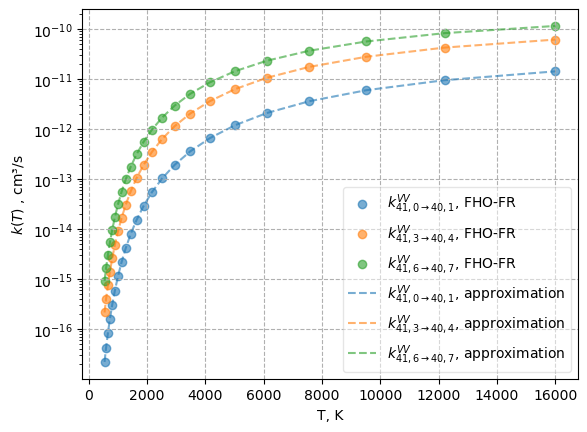

In [11]:
fig, ax = plt.subplots()
x_values = df_k.iloc[:, 0] 

x_values_test = df_test.iloc[:, 0]

for i in range(1, df_k.shape[1], 3):  
    y_values = df_k.iloc[:, i]
    # ax.scatter(x_values, y_values, label=f'41, {i - 1} --> 40, {i}, расчет', color='red', alpha=0.6)
    ax.scatter(x_values, y_values, label=f'$k^{{VV}}_{{41, {i-1} \\rightarrow 40, {i}}}$, FHO-FR', alpha=0.6)
    
# for i in range(1, df_test.shape[1]):  
#     y_values = df_test.iloc[:, i]
#     # ax.scatter(x_values, y_values, label=f'41, {i - 1} --> 40, {i}, расчет', color='red', alpha=0.6)
#     ax.scatter(x_values_test, y_values, label=f'$k^{{VV}}_{{41, {i-1} \\rightarrow 40, {i}}}$, test', alpha=0.6)
    
for i in range(0, pred_values.shape[1], 3):  
    y_values = pred_values.iloc[:, i]
    # ax.plot(x_values, y_values, label=f'41, {i} --> 40, {i+1}, модель', linestyle='--', alpha=0.6)
    ax.plot(x_values, y_values, label=f'$k^{{VV}}_{{41, {i} \\rightarrow 40, {i+1}}}$, approximation', linestyle='--', alpha=0.6)
    
ax.set_yscale('log')
plt.legend(frameon=True, framealpha=0.5, fontsize='medium')
plt.grid(True, linestyle='--')

plt.xlabel('Т, K')
plt.ylabel('$k(T)$ , cm³/s')

fig.savefig('plot_VV_reg.png', dpi=600)
plt.show()


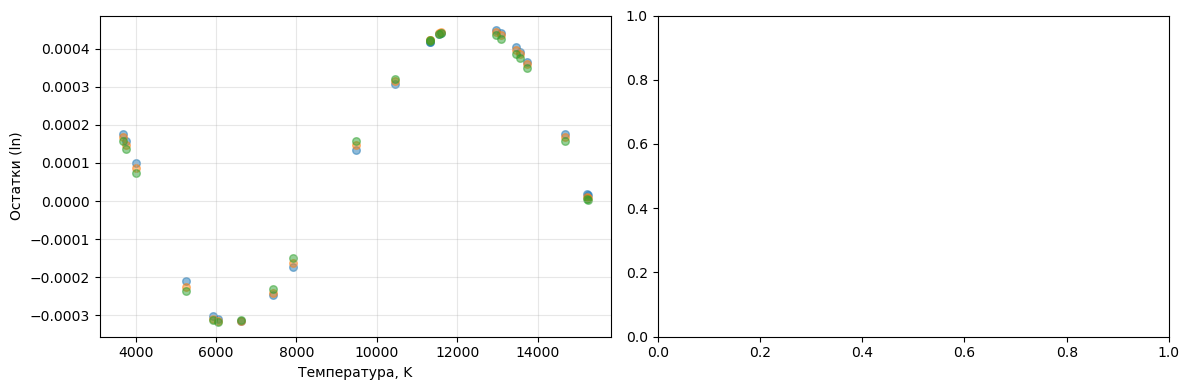

array([ 1.75418271e-04,  1.57594582e-04,  9.88977764e-05, -2.11201981e-04,
       -3.01697658e-04, -3.09920889e-04, -3.15664969e-04, -2.47959433e-04,
       -1.72431895e-04,  1.34990875e-04,  3.06607232e-04,  4.17871645e-04,
        4.18835386e-04,  4.38665389e-04,  4.41239441e-04,  4.48875928e-04,
        4.40206702e-04,  4.03472742e-04,  3.91482348e-04,  3.66073899e-04,
        1.75189458e-04,  1.87813710e-05,  1.60394467e-05,  1.67595220e-04,
        1.48239030e-04,  8.59186819e-05, -2.25461456e-04, -3.09385942e-04,
       -3.16234766e-04, -3.15458611e-04, -2.40401189e-04, -1.61705665e-04,
        1.47642765e-04,  3.15824586e-04,  4.22420318e-04,  4.23325603e-04,
        4.41799248e-04,  4.44168747e-04,  4.44497998e-04,  4.35311760e-04,
        3.97188553e-04,  3.84893256e-04,  3.58976119e-04,  1.67020064e-04,
        1.13547531e-05,  8.63335023e-06,  1.58390644e-04,  1.37888335e-04,
        7.30683359e-05, -2.35558264e-04, -3.12499632e-04, -3.18023156e-04,
       -3.11378936e-04, -

In [12]:
def test_residuals(df_test, coeffs, model_func):

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    all_residuals = []
    mape_values = []
    
    for i in range(1, df_test.shape[1]):
            k_pred = model_func(df_test.iloc[:, 0], *coeffs[i-1]) # логарифм масштаб

            # residuals = np.log(df_test.iloc[:, i] - k_pred)
            # residuals = np.log(df_test.iloc[:, i]) - k_pred
            residuals = k_pred - np.log(df_test.iloc[:, i])
            all_residuals.extend(residuals)

            mape = mape_loss(df_test.iloc[:, i], np.exp(k_pred))
            mape_values.append(mape)
  
            ax1.scatter(df_test.iloc[:, 0], residuals, alpha=0.5, s=30)
    
    all_residuals = np.array(all_residuals)

    ax1.set_xlabel('Температура, K')
    ax1.set_ylabel('Остатки (ln)')
    ax1.grid(True, alpha=0.3)
    
    # ax2.hist(all_residuals, bins=15, alpha=0.7, edgecolor='black')
    # ax2.axvline(np.mean(all_residuals), color='red', linestyle='--', 
    #             label=f'Mean: {np.mean(all_residuals):.3f}')
    # ax2.set_xlabel('Остатки')
    # ax2.set_ylabel('Частота')
    # ax2.set_title(f'MAPE среднее: {np.mean(mape_values):.4f}')
    # ax2.legend()
    # ax2.grid(True, alpha=0.3)
    # 
    plt.tight_layout()
    plt.savefig('test_residuals_quick.png', dpi=300)
    plt.show()

    # print(f"\nСтатистика остатков (тестовые данные):")
    # print(f"Всего точек: {len(all_residuals)}")
    # print(f"Среднее остатков: {np.mean(all_residuals):.6f}")
    # print(f"Ст. отклонение: {np.std(all_residuals):.6f}")
    # print(f"MAPE среднее: {np.mean(mape_values):.4f}")
    # print(f"MAPE min/max: {np.min(mape_values):.4f} / {np.max(mape_values):.4f}")
    
    return all_residuals


test_residuals(df_test, coeffs, k_model_poly)

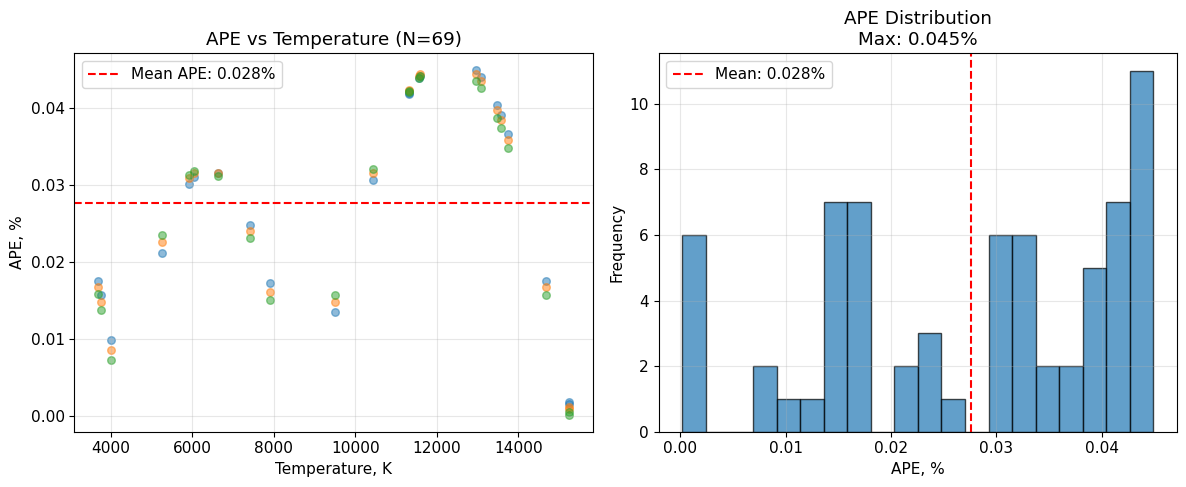

Mean APE: 0.027606%
Std APE: 0.013832%
Max APE: 0.044897%


In [66]:
def plot_APE_test(df_test, coeffs, model_func):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    all_ape = []
    
    for i in range(1, df_test.shape[1]):
        y_exp = df_test.iloc[:, i]
        k_pred = np.exp(model_func(df_test.iloc[:, 0], *coeffs[i-1]))
        
        ape = 100 * np.abs((y_exp - k_pred) / y_exp)
        all_ape.extend(ape)
        
        ax1.scatter(df_test.iloc[:, 0], ape, alpha=0.5, s=30)
    
    all_ape = np.array(all_ape)
    
    ax1.axhline(y=np.mean(all_ape), color='red', linestyle='--', 
                label=f'Mean APE: {np.mean(all_ape):.3f}%')
    ax1.set_xlabel('Temperature, K')
    ax1.set_ylabel('APE, %')
    ax1.set_title(f'APE vs Temperature (N={len(all_ape)})')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    ax2.hist(all_ape, bins=20, alpha=0.7, edgecolor='black')
    ax2.axvline(np.mean(all_ape), color='red', linestyle='--',
                label=f'Mean: {np.mean(all_ape):.3f}%')
    ax2.set_xlabel('APE, %')
    ax2.set_ylabel('Frequency')
    ax2.set_title(f'APE Distribution\nMax: {np.max(all_ape):.3f}%')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Mean APE: {np.mean(all_ape):.6f}%")
    print(f"Std APE: {np.std(all_ape):.6f}%")
    print(f"Max APE: {np.max(all_ape):.6f}%")
    
    return all_ape

# Использование
ape_values = plot_APE_test(df_test, coeffs, k_model_poly)

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import csv
import time

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.linear_model import SGDRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_squared_log_error

from scipy.optimize import least_squares

In [4]:
def get_coef(coef, T, coef_num):
    A = np.polynomial.polynomial.Polynomial(coef=coef[0:coef_num])
    #B = np.polynomial.polynomial.Polynomial(coef=coef[coef_num:2*coef_num])
    #C = np.polynomial.polynomial.Polynomial(coef=coef[2*coef_num:])
    return A(T**(-1/3))#*np.exp(B(T**(-1/3))) #+ C(T**(-1/3))

def mape_loss(coef, T, k, coef_num, regul_coef):
    A = np.polynomial.polynomial.Polynomial(coef=coef[0:coef_num])
    #B = np.polynomial.polynomial.Polynomial(coef=coef[coef_num:2*coef_num])
    #C = np.polynomial.polynomial.Polynomial(coef=coef[2*coef_num:])
    pred_val = A(T**(-1/3))#*np.exp(B(T**(-1/3))) #+ C(T**(-1/3))
    return np.abs((k - pred_val)/k) + regul_coef*np.sum(np.abs(coef))

def smape_loss(coef, T, k, coef_num, regul_coef):
    A = np.polynomial.polynomial.Polynomial(coef=coef[0:coef_num])
    #B = np.polynomial.polynomial.Polynomial(coef=coef[coef_num:2*coef_num])
    #C = np.polynomial.polynomial.Polynomial(coef=coef[2*coef_num:])
    pred_val = A(T**(-1/3))#*np.exp(B(T**(-1/3))) #+ C(T**(-1/3))
    return np.abs(pred_val - k)/(np.abs(pred_val)+np.abs(k))/2 + regul_coef*np.sum(coef**2)
    
def rmsle_loss(coef, T, k, coef_num, regul_coef):
    A = np.polynomial.polynomial.Polynomial(coef=coef[0:coef_num])
    B = np.polynomial.polynomial.Polynomial(coef=coef[coef_num:2*coef_num])
    C = np.polynomial.polynomial.Polynomial(coef=coef[2*coef_num:])
    pred_val = A(T**(-1/3))*np.exp(B(T**(-1/3))) + C(T**(-1/3))
    return np.log((k+1)/(pred_val+1))**2

1
BEST_POLY_LEN: 6
BEST SCORE: 0.0006172865212848263
BEST COEFS: [-8.27051915e-01  1.17126383e+01 -3.47292942e+02  3.66239768e+03
 -1.94872947e+04  4.14902910e+04]


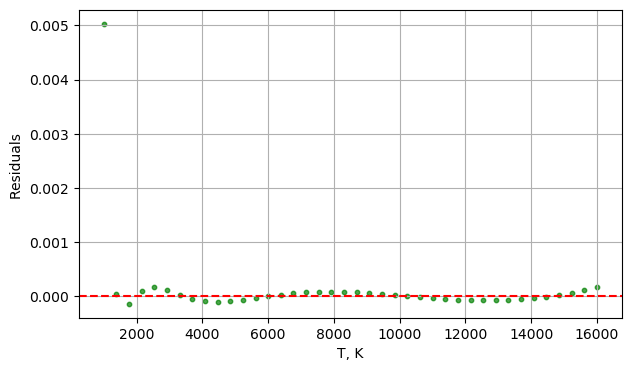

--- 6.544633150100708 seconds ---
2
BEST_POLY_LEN: 6
BEST SCORE: 0.0006626938391956808
BEST COEFS: [-8.25463192e-01  1.16064843e+01 -3.41274458e+02  3.54510931e+03
 -1.85516172e+04  3.87446415e+04]


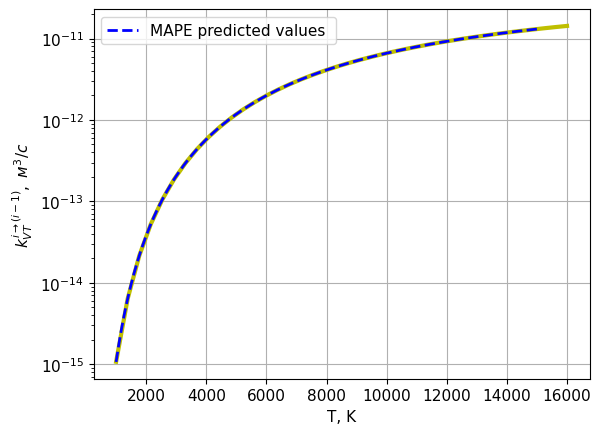

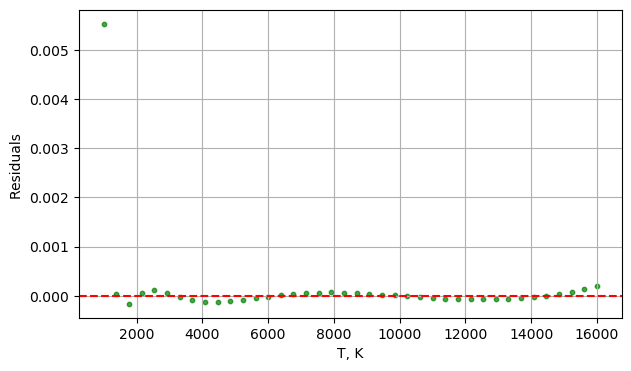

--- 6.509130954742432 seconds ---
3


ValueError: With n_samples=0, test_size=0.3 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

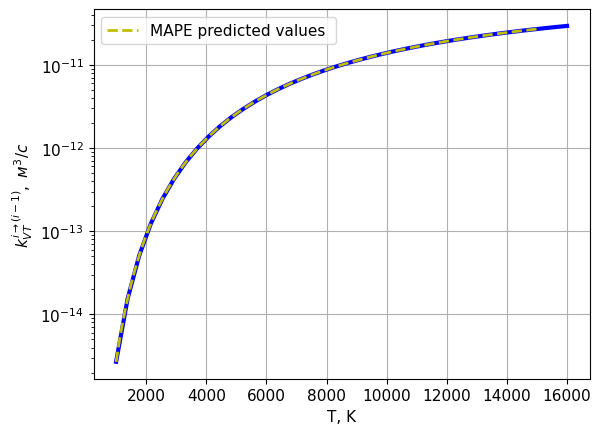

In [12]:
# df = pd.read_csv('kvt_FHO-FR_MM_O2-O2_FULL.txt', sep=' ')
df = pd.read_csv('N2_long.csv')

plt.style.use('default')

mape_i_err = []

with open('coefs.txt', 'w') as coef_file:
    max_poly_len = 6
    for k in range(1,36):
        start_time = time.time()
        print(k)
        X = df[df['i']==k]['T']
        y = np.log(df[df['i']==k]['kVT'])
        norm_y = y.abs().max()
        y = y / norm_y

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

        T_1 = X.min()
        T_2 = 15000

        X_for_score1 = df[(df['T'] >= T_1) & (df['T'] <= T_2) & (df['i'] == k)]['T']
        y_for_score = np.log(df[(df['T'] >= T_1) & (df['T'] <= T_2) & (df['i'] == k)]['kVT']) / norm_y

        X_for_figure1 = np.linspace(T_1, T_2, 100000)

        best_score1 = 100

        for i in range(1,max_poly_len+1): 
                #print(i)
                coef_num = i
                regul_coef= 0 #1e1
                x0 = np.ones(coef_num)#*1e-15

                res_mape = least_squares(mape_loss, 
                                         x0, 
                                         method='lm', 
                                         args=(X_train, y_train, coef_num, regul_coef))

                y_mape = np.array([get_coef(res_mape.x, xs, coef_num) for xs in X_for_figure1])
                

                #if np.all(y_mape > 0):
                    #print(f"Coefs: {res_mape.x}")

                MAPE_score1 = np.sum([mape_loss(res_mape.x, *pair, coef_num, 0) for pair in zip(X_for_score1, y_for_score)])/len(X_for_score1)*100
                #print(f'MAPE_score: {MAPE_score1} %')

                if MAPE_score1 < best_score1:
                    best_score1 = MAPE_score1
                    best_coefs1 = res_mape.x
                    poly_len1 = i
                    mape_i_err.append([get_coef(res_mape.x, xs, coef_num) for xs in X])

                    # plt.plot(X, y, label=r'$k_{VT}^{1 \to 0}~FHO-FR$')
                    # plt.plot(X_for_figure1, y_mape, label='MAPE loss')
                    # plt.yscale("logit")
                    # plt.xlabel("T, K")
                    # plt.ylabel("k")
                    # plt.grid()
                    # plt.legend()
                    # plt.show()

        print(f'BEST_POLY_LEN: {poly_len1}')
        print(f'BEST SCORE: {best_score1}')
        print(f'BEST COEFS: {best_coefs1}')
        

        # ОСТАТКИ
   
        X_res = X.values
        y_true_norm = y.values   # log(kVT)/norm_y

        y_pred_norm = np.array([
            get_coef(best_coefs1[:poly_len1], xs, poly_len1)
            for xs in X_res
        ])
        
        residuals = (np.exp(y_true_norm * norm_y) - np.exp(y_pred_norm * norm_y) ) / np.exp(y_true_norm * norm_y)
        # residuals_log_norm = y_true_norm - y_pred_norm
        # residuals_log = residuals_log * norm_y
        plt.style.use('default')

        plt.figure(figsize=(7,4))
        plt.scatter(X_res, residuals, s=10, alpha=0.7, color='green')
        # plt.scatter(X_res, np.log(np.absolute(residuals)), s=10, alpha=0.7, color='green')
        # plt.scatter(X_res, residuals_log_norm, s=10, alpha=0.7, color='red')
        # plt.scatter(X_res, residuals_log, s=10, alpha=0.7, color='red')
        plt.axhline(0, color='red', linestyle='--')
        plt.xlabel("T, K")
        plt.ylabel(r"Residuals ")
        # plt.title(f"Residuals for transition {k} → {k-1}")
        plt.grid()
        plt.show()



        if len(best_coefs1) < max_poly_len: 
            best_coefs1 = list(best_coefs1) + [0]*(max_poly_len - len(best_coefs1))
        line = [norm_y, *best_coefs1]
        coef_file.write(' '.join(map(str, line)) + '\n')


        X = df[df['i']==k]['T']
        y = df[df['i']==k]['kVT']

        y_mape = np.exp(y_mape*norm_y)
        print("--- %s seconds ---" % (time.time() - start_time))
        
        levels = rf'{k} \to {k-1}'
        label_k = r'$k_{VT}^' + r'{' + levels + r'}' + r'~FHO-FR$'
        
        if k == 1:
            plt_color1 = 'y'
            plt_color2 = 'b--'
        elif k == 5:
            plt_color1 = 'g'
            plt_color2 = 'c--'
        else:
            plt_color1 = 'b'
            plt_color2 = 'y--'


        # print(f'X: {X}')
        # print(f'y: {y}')
        # print(f'X_for_figure1: {X_for_figure1}')
        # print(f'y_mape: {y_mape}')
        
        plt.rcParams.update({'font.size': 11})
        plt.plot(X, y, plt_color1, linewidth=3)
        plt.plot(X_for_figure1, y_mape, plt_color2, label='MAPE predicted values ' , linewidth=2)
        ax = plt.gca()
        #ax.set_xlim([0,10000])
        #ax.set_ylim([1e-17,1e-9])
        plt.yscale("logit")
        plt.xlabel("T, K")
        plt.ylabel(r"$k_{VT}^{i \to (i-1)},~м^3/c$")
        plt.grid()
        plt.legend()
plt.savefig(f'O2-O2_{k}->{k-1}_merged.png')
plt.show()
plt.savefig('res_regression_MM.png', dpi=500, bbox_inches='tight')